In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

In [4]:
df_train = pd.read_excel('../data/kelulusan_train.xls')
df_test = pd.read_excel('../data/kelulusan_test.xls')

In [5]:
df_train

,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,STATUS NIKAH,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,ANIK WIDAYANTI,PEREMPUAN,BEKERJA,28,BELUM MENIKAH,2.76,2.80,3.20,3.17,2.98,3.00,3.03,0.0,3.07,TERLAMBAT
1,DWI HESTYNA PRIHASTANTY,PEREMPUAN,MAHASISWA,32,BELUM MENIKAH,3.00,3.30,3.14,3.14,2.84,3.13,3.25,0.0,3.17,TERLAMBAT
2,MURYA ARIEF BASUKI,PEREMPUAN,BEKERJA,29,BELUM MENIKAH,3.50,3.30,3.70,3.29,3.53,3.72,3.73,0.0,3.54,TERLAMBAT
3,NANIK SUSANTI,PEREMPUAN,MAHASISWA,27,BELUM MENIKAH,3.17,3.41,3.61,3.36,3.48,3.63,3.46,0.0,3.41,TERLAMBAT
4,RIFKA ISTIQFARINA,PEREMPUAN,BEKERJA,29,BELUM MENIKAH,2.90,2.89,3.30,2.85,2.98,3.00,3.08,0.0,3.09,TERLAMBAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,ARY JULI SETIYANTO,LAKI - LAKI,MAHASISWA,23,BELUM MENIKAH,1.98,2.50,2.14,2.77,2.61,2.93,2.82,2.5,0.99,TEPAT
375,RINA ZAHROTUL UMAMI,PEREMPUAN,BEKERJA,23,BELUM MENIKAH,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,2.97,TEPAT
376,TULISA WAHYUHADI KRISNATAMI,PEREMPUAN,MAHASISWA,23,BELUM MENIKAH,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,3.03,TEPAT
377,NI'MATUL JANNAH,PEREMPUAN,MAHASISWA,23,BELUM MENIKAH,3.02,2.94,3.25,2.87,3.00,2.94,3.09,3.0,3.16,TEPAT


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NAMA              379 non-null    object 
 1   JENIS KELAMIN     379 non-null    object 
 2   STATUS MAHASISWA  379 non-null    object 
 3   UMUR              379 non-null    int64  
 4   STATUS NIKAH      379 non-null    object 
 5   IPS 1             379 non-null    float64
 6   IPS 2             379 non-null    float64
 7   IPS 3             379 non-null    float64
 8   IPS 4             379 non-null    float64
 9   IPS 5             379 non-null    float64
 10  IPS 6             379 non-null    float64
 11  IPS 7             379 non-null    float64
 12  IPS 8             372 non-null    float64
 13  IPK               376 non-null    float64
 14  STATUS KELULUSAN  379 non-null    object 
dtypes: float64(9), int64(1), object(5)
memory usage: 44.5+ KB


In [7]:
print(df_train['JENIS KELAMIN'].unique())
print(df_train['STATUS MAHASISWA'].unique())
print(df_train['STATUS NIKAH'].unique())
print(df_train['STATUS KELULUSAN'].unique())

['PEREMPUAN' 'LAKI - LAKI']
['BEKERJA' 'MAHASISWA']
['BELUM MENIKAH' 'MENIKAH']
['TERLAMBAT' 'TEPAT']


In [8]:
df_train.drop(columns=['STATUS NIKAH'], inplace=True)
df_test.drop(columns=['STATUS NIKAH'], inplace=True)

df_train = df_train.dropna(subset=['IPS 8'])
df_train = df_train.dropna(subset=['IPK '])

df_test = df_test.dropna(subset=['IPS 8'])
df_test = df_test.dropna(subset=['IPK '])

df_train = df_train.drop(columns=['NAMA'])
df_test = df_test.drop(columns=['NAMA'])
df_train

,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,PEREMPUAN,BEKERJA,28,2.76,2.80,3.20,3.17,2.98,3.00,3.03,0.0,3.07,TERLAMBAT
1,PEREMPUAN,MAHASISWA,32,3.00,3.30,3.14,3.14,2.84,3.13,3.25,0.0,3.17,TERLAMBAT
2,PEREMPUAN,BEKERJA,29,3.50,3.30,3.70,3.29,3.53,3.72,3.73,0.0,3.54,TERLAMBAT
3,PEREMPUAN,MAHASISWA,27,3.17,3.41,3.61,3.36,3.48,3.63,3.46,0.0,3.41,TERLAMBAT
4,PEREMPUAN,BEKERJA,29,2.90,2.89,3.30,2.85,2.98,3.00,3.08,0.0,3.09,TERLAMBAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,LAKI - LAKI,MAHASISWA,23,1.98,2.50,2.14,2.77,2.61,2.93,2.82,2.5,0.99,TEPAT
375,PEREMPUAN,BEKERJA,23,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,2.97,TEPAT
376,PEREMPUAN,MAHASISWA,23,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,3.03,TEPAT
377,PEREMPUAN,MAHASISWA,23,3.02,2.94,3.25,2.87,3.00,2.94,3.09,3.0,3.16,TEPAT


In [9]:
replacements = {
    'JENIS KELAMIN': {'LAKI - LAKI': 1, 'PEREMPUAN': 0},
    'STATUS MAHASISWA': {'MAHASISWA': 0, 'BEKERJA': 1},
    'STATUS KELULUSAN': {'TERLAMBAT': 1, 'TEPAT': 0}
}

df_train = df_train.replace(replacements)
df_train

C:\Users\kenas\AppData\Local\Temp\ipykernel_20348\69606298.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train = df_train.replace(replacements)


,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,0,1,28,2.76,2.80,3.20,3.17,2.98,3.00,3.03,0.0,3.07,1
1,0,0,32,3.00,3.30,3.14,3.14,2.84,3.13,3.25,0.0,3.17,1
2,0,1,29,3.50,3.30,3.70,3.29,3.53,3.72,3.73,0.0,3.54,1
3,0,0,27,3.17,3.41,3.61,3.36,3.48,3.63,3.46,0.0,3.41,1
4,0,1,29,2.90,2.89,3.30,2.85,2.98,3.00,3.08,0.0,3.09,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,1,0,23,1.98,2.50,2.14,2.77,2.61,2.93,2.82,2.5,0.99,0
375,0,1,23,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,2.97,0
376,0,0,23,2.74,2.75,2.55,3.00,2.98,2.80,3.14,3.0,3.03,0
377,0,0,23,3.02,2.94,3.25,2.87,3.00,2.94,3.09,3.0,3.16,0


In [10]:
df_test.isnull().sum()

JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               0
IPK                 0
STATUS KELULUSAN    0
dtype: int64

In [11]:
df_train.isnull().sum()

JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               0
IPK                 0
STATUS KELULUSAN    0
dtype: int64

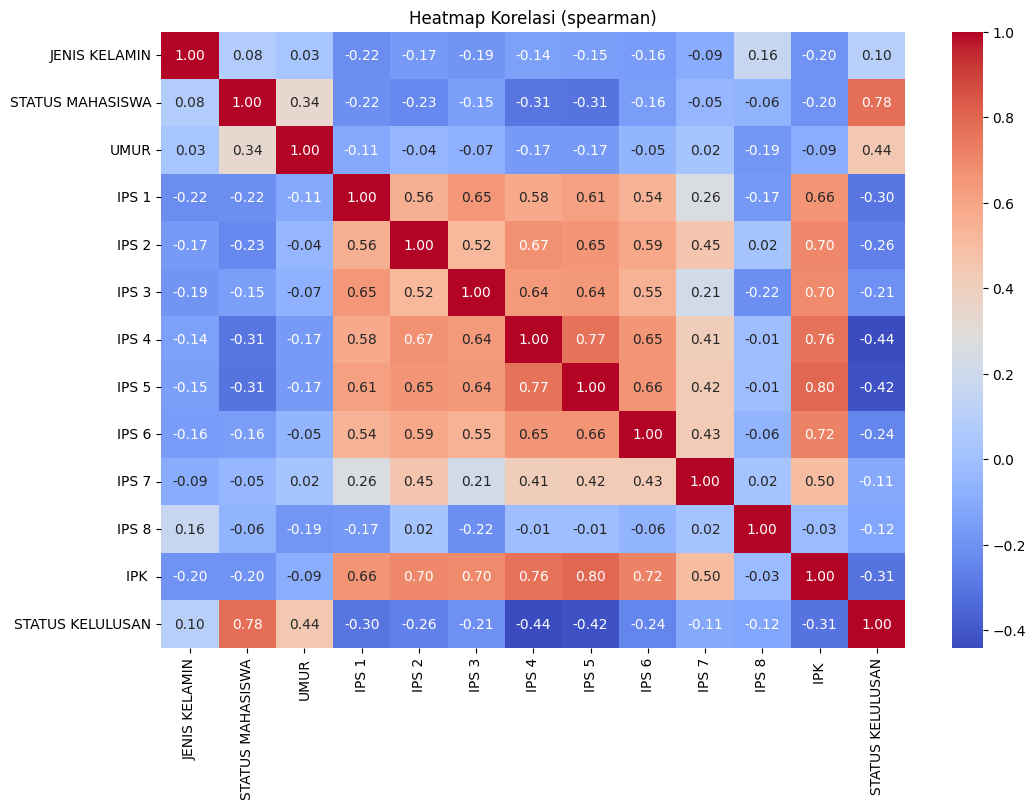

In [12]:
correlation_matrix = df_train.corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True,
            fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (spearman)")
plt.show()

In [13]:
df_train['STATUS KELULUSAN'].value_counts()

STATUS KELULUSAN
0    206
1    163
Name: count, dtype: int64

C:\Users\kenas\AppData\Local\Temp\ipykernel_20348\2780848329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='STATUS KELULUSAN', data=df_train, palette='Set2')


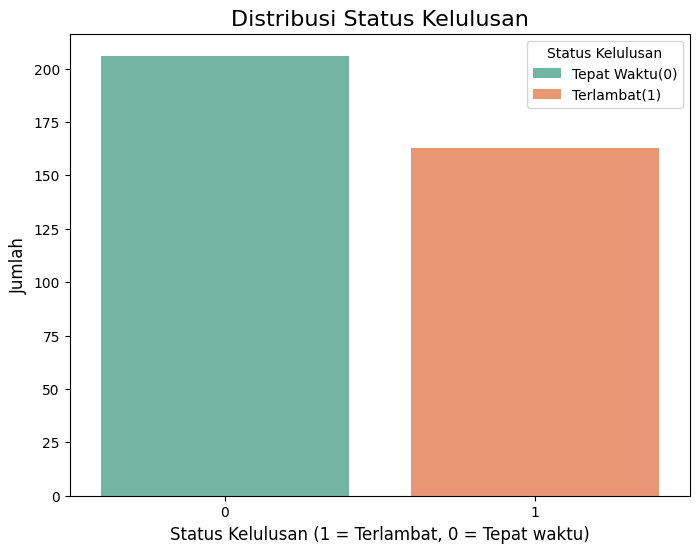

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='STATUS KELULUSAN', data=df_train, palette='Set2')

plt.title('Distribusi Status Kelulusan', fontsize=16)

plt.xlabel('Status Kelulusan (1 = Terlambat, 0 = Tepat waktu)',
           fontsize=12)

plt.ylabel('Jumlah', fontsize=12)

plt.legend(title='Status Kelulusan',
           labels=['Tepat Waktu(0)', 'Terlambat(1)'],
           loc='upper right')

plt.show()

In [15]:
df_train['JENIS KELAMIN'] = pd.to_numeric(df_train['JENIS KELAMIN'])
df_train['STATUS MAHASISWA'] = pd.to_numeric(df_train['STATUS MAHASISWA'])
df_train['STATUS KELULUSAN'] = pd.to_numeric(df_train['STATUS KELULUSAN'])

In [16]:
df_test['JENIS KELAMIN'] = pd.to_numeric(df_train['JENIS KELAMIN'])
df_test['STATUS MAHASISWA'] = pd.to_numeric(df_train['STATUS MAHASISWA'])
df_test['STATUS KELULUSAN'] = pd.to_numeric(df_train['STATUS KELULUSAN'])

In [17]:
x_train = df_train.drop(columns=['STATUS KELULUSAN'])
y_train = df_train['STATUS KELULUSAN']

x_test = df_test.drop(columns=['STATUS KELULUSAN'])
y_test = df_test['STATUS KELULUSAN']

In [29]:
y_test = y_test.dropna()

In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [31]:
print("\n--- Jumlah Kelas Sebelum SMOTE ---")
print(y_train.value_counts())

# Aplikasikan SMOTE hanya pada data training
sm = SMOTE(random_state=42, k_neighbors=1) 
x_train_smote, y_train_smote = sm.fit_resample(x_train_scaled, y_train)

print("\n--- Jumlah Kelas Setelah SMOTE ---")
print(y_train_smote.value_counts())


--- Jumlah Kelas Sebelum SMOTE ---
STATUS KELULUSAN
0    206
1    163
Name: count, dtype: int64

--- Jumlah Kelas Setelah SMOTE ---
STATUS KELULUSAN
1    206
0    206
Name: count, dtype: int64


In [32]:
# Menentukan Parameter Terbaik (Hyperparameter Tuning)
param_grid = {
    'n_neighbors': list(range(1, 31)), 
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(x_train_smote, y_train_smote)

print("\n--- Hasil Hyperparameter Tuning ---")
print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)


--- Hasil Hyperparameter Tuning ---
Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'distance'}
Best Score (CV): 0.9029973552747576


In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [34]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
# sm = SMOTE(random_state=42)
# x_train_smote, y_train_smote = sm.fit_resample(x_train_scaled, y_train)

# best_knn = grid.best_estimator_
# best_knn.fit(x_train_smote, y_train_smote)
# y_pred = best_knn.predict(x_test_scaled)

In [36]:
# Melatih Model KNN Terbaik dan Melakukan Prediksi
best_knn = grid.best_estimator_

# Melatih model menggunakan data training hasil SMOTE dan parameter terbaik
best_knn.fit(x_train_smote, y_train_smote)

# Prediksi pada data testing (X_test_scaled)
y_pred = best_knn.predict(x_test_scaled)

print("\nModel KNN terbaik sudah dilatih dan prediksi telah dilakukan pada data uji.")


Model KNN terbaik sudah dilatih dan prediksi telah dilakukan pada data uji.


In [41]:
# 1. Pisahkan fitur & label dari awal
x = df_train.drop(columns=['STATUS KELULUSAN'])
y = df_train['STATUS KELULUSAN']

# 2. Train-test split ulang
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# 3. Scaling ulang
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 4. Prediksi ulang
y_pred = best_knn.predict(x_test_scaled)

In [42]:
len(y_test), len(y_pred)

(111, 111)


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        53

    accuracy                           1.00       111
   macro avg       1.00      1.00      1.00       111
weighted avg       1.00      1.00      1.00       111



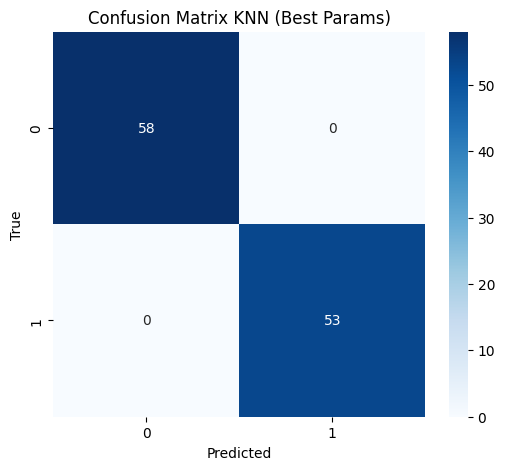


--- Hasil Cross Validation ---
Cross Validation Accuracy: 0.9029973552747576
Std Dev: 0.042371318661662674


In [45]:
# 10. Evaluasi Model dengan Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 11. Evaluasi dengan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 12. Validasi Model dengan Cross Validation (pada data training SMOTE)
cv_scores = cross_val_score(best_knn, x_train_smote, y_train_smote, cv=5)
print("\n--- Hasil Cross Validation ---")
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())